18 cars passing a certain tollboth at different time of the day (x) with different speed (y)

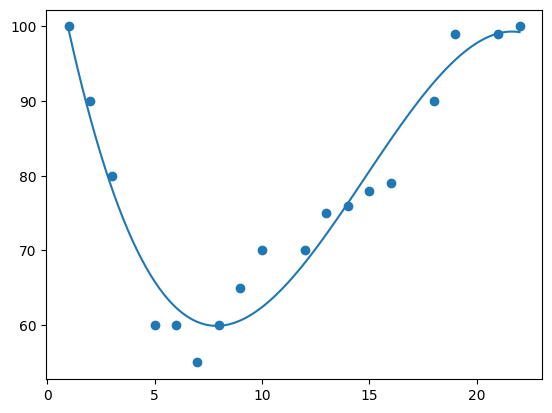

In [1]:
import numpy
import matplotlib.pyplot as plt

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

#NumPy has a method that lets us make a polynomial model
mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

#specify how the line will display, we start at position 1, and end at position 22
myline = numpy.linspace(1, 22, 100)

plt.scatter(x, y)
plt.plot(myline, mymodel(myline))
plt.show()

It is important to know how well the relationship between the values of the x- and y-axis is, if there are no relationship the polynomial regression can not be used to predict anything.

The relationship is measured with a value called the r-squared.

The r-squared value ranges from 0 to 1, where 0 means no relationship, and 1 means 100% related

In [2]:
import numpy
from sklearn.metrics import r2_score

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

print(r2_score(y, mymodel(x)))

0.9432150416451026


## Predict Future Values

Let us try to predict the speed of a car that passes the tollbooth at around 17 P.M

In [3]:
import numpy
from sklearn.metrics import r2_score

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

speed = mymodel(17)
print(speed)

88.87331269697997


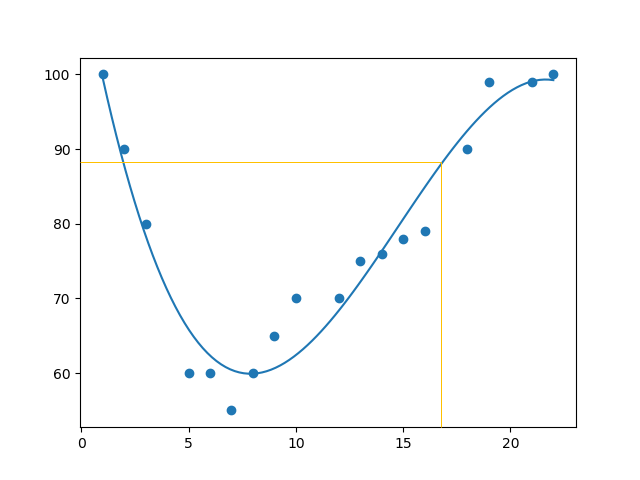

## Experiment: Changing the Data Points

The same code from above is reused below, but the `x` and `y` variables are changed to see how different data patterns affect the polynomial fit and the r-squared value. Everything except the data values (`x`, `y`) is left exactly as it was.

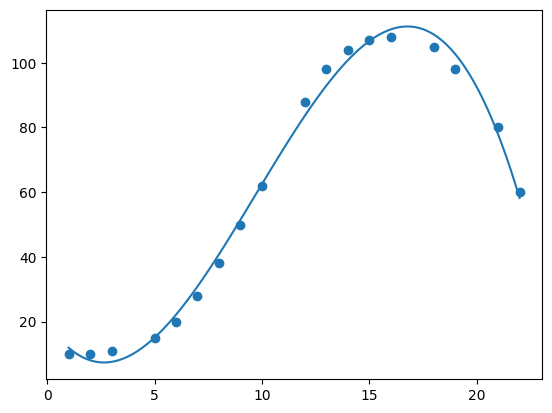

In [4]:
import numpy
import matplotlib.pyplot as plt

#Data that follows a smooth, clearly curved pattern with very little noise
x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [10,10,11,15,20,28,38,50,62,88,98,104,107,108,105,98,80,60]

#NumPy has a method that lets us make a polynomial model
mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

#specify how the line will display, we start at position 1, and end at position 22
myline = numpy.linspace(1, 22, 100)

plt.scatter(x, y)
plt.plot(myline, mymodel(myline))
plt.show()


In [5]:
import numpy
from sklearn.metrics import r2_score

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [10,10,11,15,20,28,38,50,62,88,98,104,107,108,105,98,80,60]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

print(r2_score(y, mymodel(x)))


0.9941531124771007


**Observation (smooth, low-noise data):** Because this data follows a clean curve with barely any scatter, the r-squared value comes out to about 0.994 — even higher than the original data's 0.943, meaning the cubic polynomial explains nearly all of the variation in y. The curve visually passes right through nearly every point.

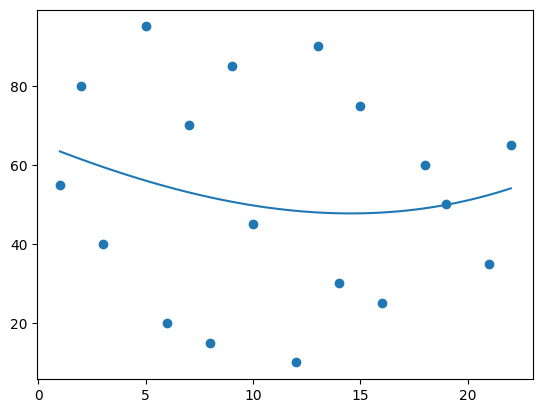

In [6]:
import numpy
import matplotlib.pyplot as plt

#Data where y is mostly random relative to x, with little real pattern
x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [55,80,40,95,20,70,15,85,45,10,90,30,75,25,60,50,35,65]

#NumPy has a method that lets us make a polynomial model
mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

#specify how the line will display, we start at position 1, and end at position 22
myline = numpy.linspace(1, 22, 100)

plt.scatter(x, y)
plt.plot(myline, mymodel(myline))
plt.show()


In [7]:
import numpy
from sklearn.metrics import r2_score

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [55,80,40,95,20,70,15,85,45,10,90,30,75,25,60,50,35,65]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

print(r2_score(y, mymodel(x)))


0.03298727972724247


**Observation (noisy/random data):** With y-values that jump around unpredictably instead of following a curve, the r-squared value drops to about 0.033 — dramatically lower than the original data's 0.943. The polynomial curve still gets drawn (numpy.polyfit will always return coefficients), but it barely tracks the scattered points, confirming that a low r-squared means the model is a poor fit and shouldn't be trusted for predictions.

### Summary of Observations: How Data Changes Affect Polynomial Regression

Comparing the original tollbooth data with the smooth low-noise data and the noisy/random data:

- **r-squared reflects how well the curve fits the actual points.** The original data (18 points, cubic fit) already had a fairly high r-squared of about 0.943. The smooth, low-noise data pushed it even higher, to about 0.994, while the noisy/random data collapsed it down to about 0.033.
- **A polynomial curve is always generated, whether or not it's meaningful.** `numpy.polyfit` will fit *some* curve to any set of points, but the r-squared value is what tells us whether that curve actually represents a real relationship or is just fitting noise.
- **Predictions are only as good as the underlying r-squared.** In the original notebook, the model was used to predict a car's speed at x=17 (about 88.9). That prediction is trustworthy when r-squared is high (as with the original and low-noise data), but with the noisy data set a prediction at any x-value would be little better than a guess.
- **Shape of the data drives the shape of the curve.** Because a degree-3 polynomial has limited flexibility, data with a genuinely curved (e.g., rise-then-fall) pattern is fit well, while data with no consistent pattern forces the curve to compromise and stay far from many points.

In short: changing the data points directly changes the r-squared value, and r-squared is the key indicator of whether a polynomial regression model is reliable for making predictions.